# 1. Data Cleaning and Auditing

The Formula 1 dataset consists of 14 relational CSV tables. Before constructing the
modeling dataset, the raw data is explored and audited to identify missing values,
incorrect data types, duplicate records, and relational-integrity problems.

The cleaning process includes:
- exploratory data analysis before cleaning;
- detection and cleaning of `\N` sentinel values;
- semantic typing of dates and durations;
- primary-key and foreign-key validation;
- investigation and resolution of duplicate `(raceId, driverId)` records;
- and exploratory analysis after cleaning.

The original DataFrames are preserved unchanged. All cleaning operations are
performed on separate copies.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

In [7]:
DATA_PATH = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020"

file_names = [
    "circuits",
    "constructors",
    "constructor_results",
    "constructor_standings",
    "drivers",
    "driver_standings",
    "races",
    "results",
    "qualifying",
    "lap_times",
    "pit_stops",
    "sprint_results",
    "seasons",
    "status"
]

raw_data = {}

for name in file_names:
    raw_data[name] = pd.read_csv(
        f"{DATA_PATH}/{name}.csv"
    )

print("Number of tables loaded:", len(raw_data))

Number of tables loaded: 14


In [8]:
for name, df in raw_data.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

circuits: 77 rows, 9 columns
constructors: 212 rows, 5 columns
constructor_results: 12625 rows, 5 columns
constructor_standings: 13391 rows, 7 columns
drivers: 861 rows, 9 columns
driver_standings: 34863 rows, 7 columns
races: 1125 rows, 18 columns
results: 26759 rows, 18 columns
qualifying: 10494 rows, 9 columns
lap_times: 589081 rows, 6 columns
pit_stops: 11371 rows, 7 columns
sprint_results: 360 rows, 16 columns
seasons: 75 rows, 2 columns
status: 139 rows, 2 columns


In [9]:
for name, df in raw_data.items():
    print(f"\n{name.upper()}")
    display(df.head())


CIRCUITS


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park



CONSTRUCTORS


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso



CONSTRUCTOR_RESULTS


...

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1
3,4,1061,844,6,16,4,4,4,4,0,17,+11.278,1549704,16,1:30.163,1
4,5,1061,846,1,4,6,5,5,5,0,17,+24.111,1562537,16,1:30.566,1



SEASONS


,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
3,2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
4,2005,http://en.wikipedia.org/wiki/2005_Formula_One_...



STATUS


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


## 1.1 Initial Exploratory Data Analysis

The raw tables are first explored without modification. Their dimensions, data types,
summary statistics, missing values, duplicate rows, and placeholder values are
examined programmatically.

This provides a baseline for identifying cleaning requirements and allows the effect
of cleaning to be evaluated later.

In [12]:
overview = []

for name, df in raw_data.items():
    overview.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

overview_df = pd.DataFrame(overview)

display(overview_df)

,Table,Rows,Columns
0,circuits,77,9
1,constructors,212,5
2,constructor_results,12625,5
3,constructor_standings,13391,7
4,drivers,861,9
5,driver_standings,34863,7
6,races,1125,18
7,results,26759,18
8,qualifying,10494,9
9,lap_times,589081,6


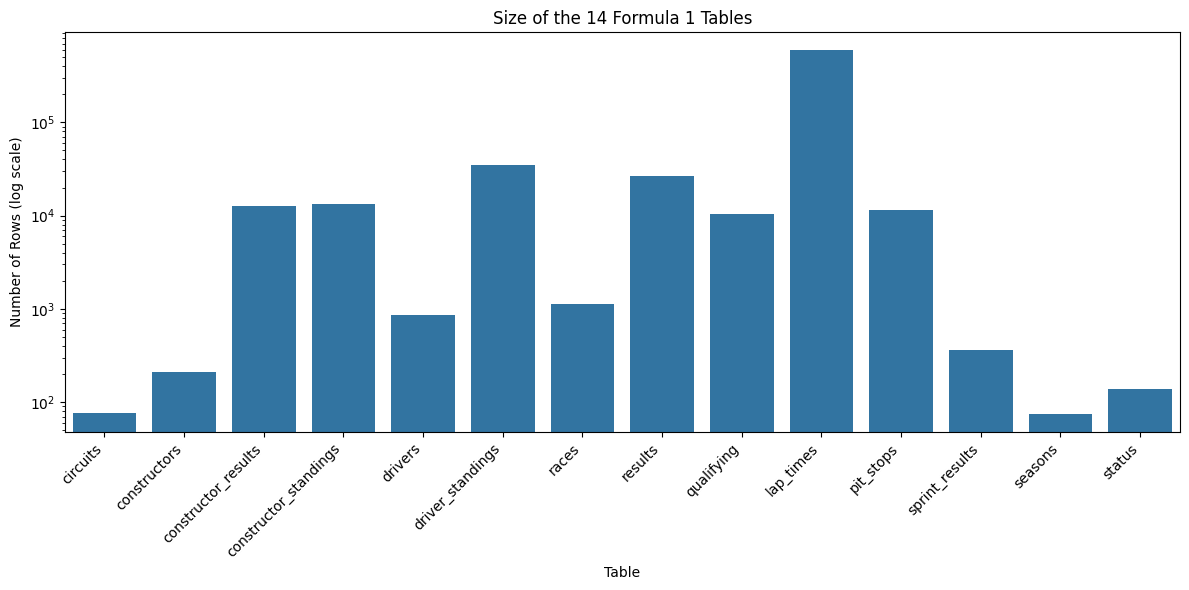

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=overview_df,
    x="Table",
    y="Rows"
)

plt.yscale("log")
plt.title("Size of the 14 Formula 1 Tables")
plt.xlabel("Table")
plt.ylabel("Number of Rows (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
for name, df in raw_data.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    df.info()


CIRCUITS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     object 
 2   name        77 non-null     object 
 3   location    77 non-null     object 
 4   country     77 non-null     object 
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ KB

CONSTRUCTORS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   212 non-null    int64 
 1   constructorRef  212 non-null    object
 2   name            212 non-null    object
 3   nationality     212 non-null    

In [15]:
for name, df in raw_data.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    display(df.describe())


CIRCUITS


,circuitId,lat,lng,alt
count,77.000000,77.000000,77.000000,77.000000
mean,39.883117,33.442925,1.076683,247.012987
std,23.001701,22.808866,65.516951,362.738469
min,1.000000,-37.849700,-118.189000,-7.000000
25%,20.000000,32.777400,-9.394170,18.000000
50%,40.000000,40.951700,3.930830,129.000000
75%,59.000000,46.958900,19.248600,332.000000
max,80.000000,57.265300,144.968000,2227.000000



CONSTRUCTORS


,constructorId
count,212.000000
mean,107.547170
std,61.952685
min,1.000000
25%,54.750000
50%,107.500000
75%,160.250000
max,215.000000



CONSTRUCTOR_RESULTS


...

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,statusId
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,180.500000,1106.944444,734.658333,94.366667,28.177778,9.922222,10.500000,1.550000,19.583333,3.336111
std,104.067286,25.636134,276.412115,89.166421,23.796293,5.842363,5.774307,2.496293,4.752803,13.447963
min,1.000000,1061.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,90.750000,1084.000000,822.000000,6.000000,11.000000,5.000000,5.750000,0.000000,18.000000,1.000000
50%,180.500000,1112.500000,840.000000,84.000000,22.000000,10.000000,10.500000,0.000000,19.000000,1.000000
75%,270.250000,1126.000000,848.000000,210.000000,44.000000,15.000000,15.250000,3.000000,24.000000,1.000000
max,360.000000,1143.000000,861.000000,215.000000,99.000000,20.000000,20.000000,8.000000,24.000000,130.000000



SEASONS


,year
count,75.000000
mean,1987.000000
std,21.794495
min,1950.000000
25%,1968.500000
50%,1987.000000
75%,2005.500000
max,2024.000000



STATUS


,statusId
count,139.000000
mean,71.237410
std,41.092434
min,1.000000
25%,35.500000
50%,72.000000
75%,106.500000
max,141.000000


In [16]:
duplicate_summary = []

for name, df in raw_data.items():
    duplicate_summary.append({
        "Table": name,
        "Exact_Duplicate_Rows": df.duplicated().sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

display(duplicate_summary)

,Table,Exact_Duplicate_Rows
0,circuits,0
1,constructors,0
2,constructor_results,0
3,constructor_standings,0
4,drivers,0
5,driver_standings,0
6,races,0
7,results,0
8,qualifying,0
9,lap_times,0


## 1.2 Sentinel and Missing-Value Analysis

The Formula 1 CSV files use the literal string `\N` as a sentinel representing
missing or unavailable information.

Because `\N` is a text placeholder rather than a proper missing value, its frequency
is measured before cleaning. Both the number and percentage of sentinel values are
calculated for each affected column and visualized before any replacement is made.

In [17]:
sentinel_summary = []

for table_name, df in raw_data.items():
    for column in df.columns:

        count = (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

        if count > 0:
            sentinel_summary.append({
                "Table": table_name,
                "Column": column,
                "Count": count,
                "Percentage": count / len(df) * 100
            })

sentinel_summary = pd.DataFrame(sentinel_summary)

sentinel_summary = sentinel_summary.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)

display(sentinel_summary)

,Table,Column,Count,Percentage
0,constructor_results,status,12608,99.865347
1,races,sprint_time,1110,98.666667
2,races,sprint_date,1107,98.400000
3,races,fp3_time,1072,95.288889
4,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
6,races,quali_time,1057,93.955556
7,races,fp3_date,1053,93.600000
8,drivers,number,802,93.147503
9,races,fp1_date,1035,92.000000


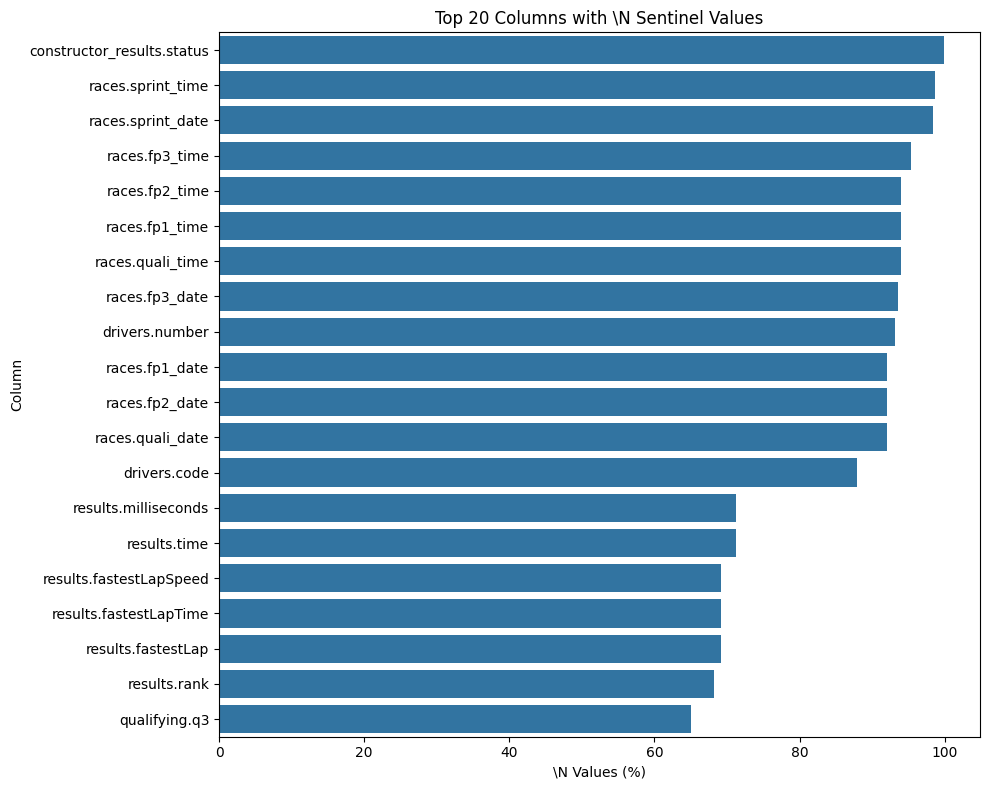

In [18]:
top_sentinels = sentinel_summary.head(20).copy()

top_sentinels["Feature"] = (
    top_sentinels["Table"]
    + "."
    + top_sentinels["Column"]
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_sentinels,
    x="Percentage",
    y="Feature"
)

plt.title("Top 20 Columns with \\N Sentinel Values")
plt.xlabel("\\N Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [19]:
missing_before = []

for table_name, df in raw_data.items():
    for column in df.columns:

        null_count = df[column].isnull().sum()

        sentinel_count = (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

        total_missing = null_count + sentinel_count

        if total_missing > 0:
            missing_before.append({
                "Table": table_name,
                "Column": column,
                "Missing_Count": total_missing,
                "Missing_Percentage": total_missing / len(df) * 100
            })

missing_before = pd.DataFrame(missing_before)

missing_before = missing_before.sort_values(
    "Missing_Percentage",
    ascending=False
).reset_index(drop=True)

display(missing_before.head(30))

,Table,Column,Missing_Count,Missing_Percentage
0,constructor_results,status,12608,99.865347
1,races,sprint_time,1110,98.666667
2,races,sprint_date,1107,98.400000
3,races,fp3_time,1072,95.288889
4,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
6,races,quali_time,1057,93.955556
7,races,fp3_date,1053,93.600000
8,drivers,number,802,93.147503
9,races,fp1_date,1035,92.000000


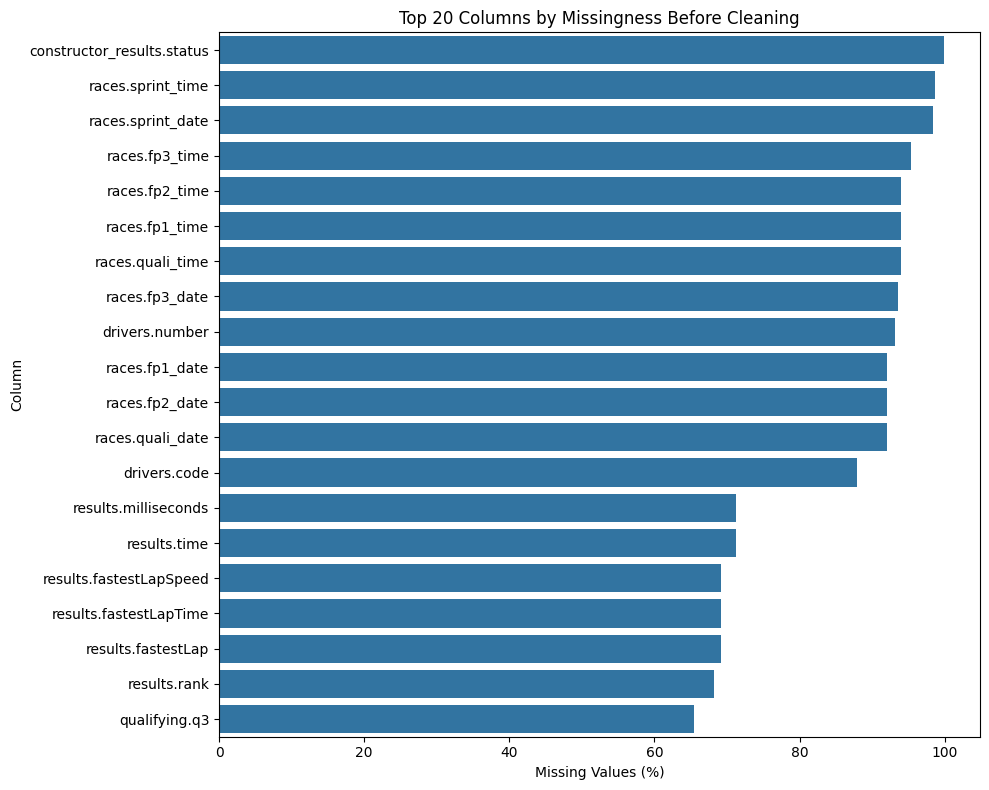

In [20]:
top_missing_before = missing_before.head(20).copy()

top_missing_before["Feature"] = (
    top_missing_before["Table"]
    + "."
    + top_missing_before["Column"]
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_missing_before,
    x="Missing_Percentage",
    y="Feature"
)

plt.title("Top 20 Columns by Missingness Before Cleaning")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

## 1.3 Cleaning Copies

The original tables stored in `raw_data` are preserved without modification.
Independent copies are created in `clean_data`, and all subsequent transformations
are applied only to these copies.

This allows the original source data to remain available for auditing and for direct
before-versus-after comparisons.

In [21]:
clean_data = {
    name: df.copy()
    for name, df in raw_data.items()
}

print("Cleaning copies created:", len(clean_data))

Cleaning copies created: 14


## 1.4 Cleaning Sentinel Values

All `\N` sentinel values are converted to `NaN`, Pandas' standard representation of
missing data.

Since the final objective is to predict whether a driver finishes on the podium, not
every column in the 14 source tables will be used as a predictive feature. Therefore,
missing values are not dropped or imputed at this stage. Instead, they are represented
correctly as `NaN`, and their treatment will be determined later for the features
selected for the final modeling table.

In [22]:
for name in clean_data:
    clean_data[name] = clean_data[name].replace(
        r"^\s*\\N\s*$",
        np.nan,
        regex=True
    )

print("Sentinel replacement complete.")

Sentinel replacement complete.


In [23]:
remaining_sentinels = 0

for name, df in clean_data.items():
    for column in df.columns:

        remaining_sentinels += (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

print("Remaining \\N sentinel values:", remaining_sentinels)

Remaining \N sentinel values: 0


## 1.5 Semantic Data Types

Several fields are stored as strings even though they represent dates or durations.

Race dates and driver dates of birth are converted to datetime values. Formula 1
duration strings are converted to numeric seconds so that their numerical meaning
is represented correctly.

The original duration columns are retained and new `_seconds` columns are created,
preserving the source representation while providing a numerical version for analysis.

In [24]:
clean_data["races"]["date"] = pd.to_datetime(
    clean_data["races"]["date"],
    errors="coerce"
)

clean_data["drivers"]["dob"] = pd.to_datetime(
    clean_data["drivers"]["dob"],
    errors="coerce"
)

print("races.date:", clean_data["races"]["date"].dtype)
print("drivers.dob:", clean_data["drivers"]["dob"].dtype)

races.date: datetime64[ns]
drivers.dob: datetime64[ns]


In [25]:
def time_to_seconds(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "":
        return np.nan

    parts = value.split(":")

    try:
        if len(parts) == 1:
            return float(parts[0])

        elif len(parts) == 2:
            minutes = float(parts[0])
            seconds = float(parts[1])

            return minutes * 60 + seconds

        elif len(parts) == 3:
            hours = float(parts[0])
            minutes = float(parts[1])
            seconds = float(parts[2])

            return hours * 3600 + minutes * 60 + seconds

    except ValueError:
        return np.nan

    return np.nan

In [26]:
duration_columns = {
    "results": ["time", "fastestLapTime"],
    "qualifying": ["q1", "q2", "q3"],
    "lap_times": ["time"],
    "pit_stops": ["duration"],
    "sprint_results": ["time", "fastestLapTime"]
}

for table_name, columns in duration_columns.items():

    for column in columns:

        if column in clean_data[table_name].columns:

            clean_data[table_name][
                f"{column}_seconds"
            ] = (
                clean_data[table_name][column]
                .apply(time_to_seconds)
            )

print("Duration conversion complete.")

Duration conversion complete.


In [27]:
print("Date types:")
print("races.date =", clean_data["races"]["date"].dtype)
print("drivers.dob =", clean_data["drivers"]["dob"].dtype)

print("\nDuration types:")
print(
    "qualifying.q1_seconds =",
    clean_data["qualifying"]["q1_seconds"].dtype
)

print(
    "lap_times.time_seconds =",
    clean_data["lap_times"]["time_seconds"].dtype
)

print(
    "pit_stops.duration_seconds =",
    clean_data["pit_stops"]["duration_seconds"].dtype
)

display(
    clean_data["qualifying"][
        ["q1", "q1_seconds", "q2", "q2_seconds", "q3", "q3_seconds"]
    ].head(10)
)

Date types:
races.date = datetime64[ns]
drivers.dob = datetime64[ns]

Duration types:
qualifying.q1_seconds = float64
lap_times.time_seconds = float64
pit_stops.duration_seconds = float64


,q1,q1_seconds,q2,q2_seconds,q3,q3_seconds
0,1:26.572,86.572,1:25.187,85.187,1:26.714,86.714
1,1:26.103,86.103,1:25.315,85.315,1:26.869,86.869
2,1:25.664,85.664,1:25.452,85.452,1:27.079,87.079
3,1:25.994,85.994,1:25.691,85.691,1:27.178,87.178
4,1:25.960,85.960,1:25.518,85.518,1:27.236,87.236
5,1:26.427,86.427,1:26.101,86.101,1:28.527,88.527
6,1:26.295,86.295,1:26.059,86.059,1:28.687,88.687
7,1:26.381,86.381,1:26.063,86.063,1:29.041,89.041
8,1:26.919,86.919,1:26.164,86.164,1:29.593,89.593
9,1:26.702,86.702,1:25.842,85.842,NaN,NaN


## 1.6 Primary-Key Integrity

Each table's primary key is checked for two requirements:

1. Primary-key values must not be missing.
2. Primary-key values must uniquely identify rows.

Composite keys are used for tables such as lap times and pit stops, where multiple
columns together identify one observation.

In [28]:
primary_keys = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "qualifying": ["qualifyId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "sprint_results": ["resultId"],
    "seasons": ["year"],
    "status": ["statusId"]
}

pk_results = []

for table_name, keys in primary_keys.items():

    df = clean_data[table_name]

    null_count = (
        df[keys]
        .isnull()
        .any(axis=1)
        .sum()
    )

    duplicate_count = (
        df
        .duplicated(subset=keys)
        .sum()
    )

    pk_results.append({
        "Table": table_name,
        "Primary_Key": " + ".join(keys),
        "Null_PK_Rows": null_count,
        "Duplicate_PK_Rows": duplicate_count,
        "Valid": null_count == 0 and duplicate_count == 0
    })

pk_results = pd.DataFrame(pk_results)

display(pk_results)

,Table,Primary_Key,Null_PK_Rows,Duplicate_PK_Rows,Valid
0,circuits,circuitId,0,0,True
1,constructors,constructorId,0,0,True
2,constructor_results,constructorResultsId,0,0,True
3,constructor_standings,constructorStandingsId,0,0,True
4,drivers,driverId,0,0,True
5,driver_standings,driverStandingsId,0,0,True
6,races,raceId,0,0,True
7,results,resultId,0,0,True
8,qualifying,qualifyId,0,0,True
9,lap_times,raceId + driverId + lap,0,0,True


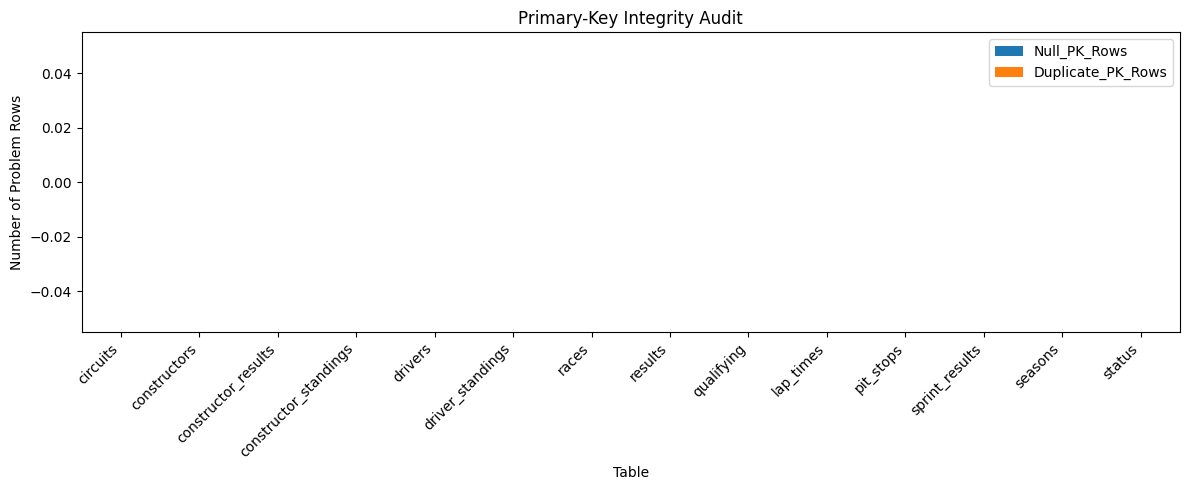

In [30]:
pk_results.set_index("Table")[
    ["Null_PK_Rows", "Duplicate_PK_Rows"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Primary-Key Integrity Audit")
plt.xlabel("Table")
plt.ylabel("Number of Problem Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 1.7 Foreign-Key Integrity

The Formula 1 dataset is relational, so foreign-key values are checked against the
corresponding primary keys in their parent tables.

For example, every `driverId` appearing in `results` should correspond to an existing
driver in `drivers`, and every `raceId` in `qualifying` should correspond to an
existing race in `races`.

An invalid reference indicates a broken relationship between tables.

In [31]:
foreign_keys = [
    ("races", "circuitId", "circuits", "circuitId"),

    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),

    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),

    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),

    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),

    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),

    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),

    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),

    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId")
]

fk_results = []

for child_table, foreign_key, parent_table, primary_key in foreign_keys:

    child_values = clean_data[child_table][foreign_key].dropna()
    parent_values = clean_data[parent_table][primary_key].dropna()

    invalid_count = (
        ~child_values.isin(parent_values)
    ).sum()

    fk_results.append({
        "Child_Table": child_table,
        "Foreign_Key": foreign_key,
        "Parent_Table": parent_table,
        "Parent_Key": primary_key,
        "Invalid_References": invalid_count,
        "Valid": invalid_count == 0
    })

fk_results = pd.DataFrame(fk_results)

display(fk_results)

,Child_Table,Foreign_Key,Parent_Table,Parent_Key,Invalid_References,Valid
0,races,circuitId,circuits,circuitId,0,True
1,results,raceId,races,raceId,0,True
2,results,driverId,drivers,driverId,0,True
3,results,constructorId,constructors,constructorId,0,True
4,results,statusId,status,statusId,0,True
5,qualifying,raceId,races,raceId,0,True
6,qualifying,driverId,drivers,driverId,0,True
7,qualifying,constructorId,constructors,constructorId,0,True
8,lap_times,raceId,races,raceId,0,True
9,lap_times,driverId,drivers,driverId,0,True


In [32]:
fk_problems = fk_results[
    fk_results["Invalid_References"] > 0
]

if fk_problems.empty:
    print("All tested foreign-key relationships reconcile successfully.")
else:
    display(fk_problems)

All tested foreign-key relationships reconcile successfully.


## 1.8 Driver-Race Grain Audit

The required unit of analysis is one driver entering one race. Therefore,
`(raceId, driverId)` must be unique in the modeling table.

Historical Formula 1 data may contain multiple result rows for the same driver in the
same race because early Formula 1 allowed shared drives, where drivers could swap cars
during a race.

These records are genuine historical observations rather than ordinary duplicate
CSV rows. They are therefore identified and investigated separately before applying
a resolution rule.

In [33]:
duplicate_mask = clean_data["results"].duplicated(
    subset=["raceId", "driverId"],
    keep=False
)

duplicate_driver_races = (
    clean_data["results"]
    .loc[duplicate_mask]
    .sort_values(
        ["raceId", "driverId", "positionOrder", "resultId"]
    )
)

duplicate_groups = (
    duplicate_driver_races[
        ["raceId", "driverId"]
    ]
    .drop_duplicates()
)

print(
    "Rows involved in duplicated driver-race groups:",
    len(duplicate_driver_races)
)

print(
    "Number of duplicated (raceId, driverId) combinations:",
    len(duplicate_groups)
)

display(duplicate_driver_races)

Rows involved in duplicated driver-race groups: 176
Number of duplicated (raceId, driverId) combinations: 85


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,time_seconds,fastestLapTime_seconds
13188,13189,540,229,54,10,0,NaN,F,26,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,81,NaN,NaN
13191,13192,540,229,57,23,0,NaN,F,29,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,97,NaN,NaN
17362,17363,717,373,172,1,1,7,7,7,0.0,102,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN,NaN
24298,24304,717,373,172,2,1,NaN,R,12,0.0,54,NaN,NaN,NaN,NaN,NaN,NaN,98,NaN,NaN
17740,17741,733,465,172,48,0,NaN,W,22,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20142,20143,838,627,154,20,6,NaN,R,12,0.0,10,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
20183,20184,839,579,51,60,7,NaN,R,13,0.0,34,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN
20163,20164,839,579,51,18,1,NaN,R,15,1.0,23,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN
20182,20183,839,647,6,48,6,2,2,2,3.0,80,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN


In [38]:
duplicate_years = duplicate_driver_races.merge(
    clean_data["races"][["raceId", "year"]],
    on="raceId",
    how="left"
)

duplicates_by_year = (
    duplicate_years
    .groupby("year")
    .size()
    .reset_index(name="Duplicate_Rows")
)

display(duplicates_by_year)

,year,Duplicate_Rows
0,1950,8
1,1951,8
2,1952,6
3,1953,30
4,1954,33
5,1955,33
6,1956,24
7,1957,16
8,1958,6
9,1960,2


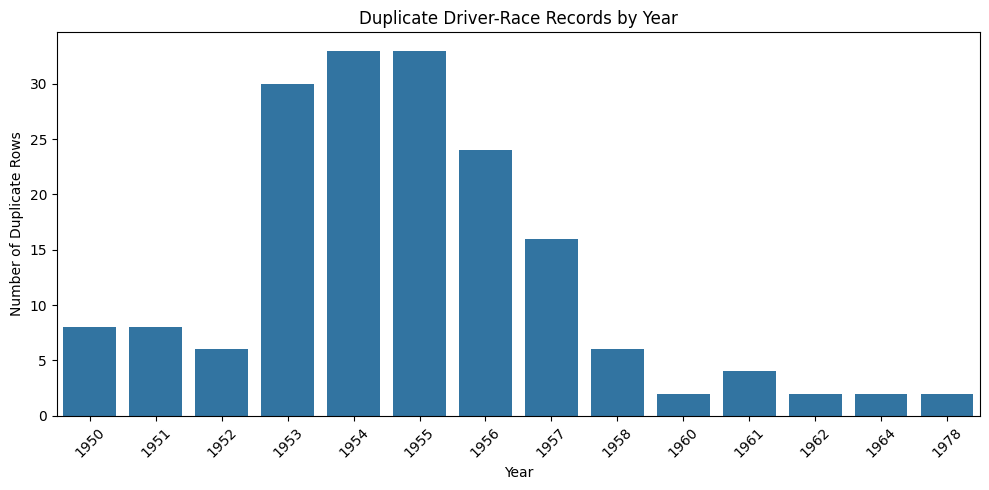

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=duplicates_by_year,
    x="year",
    y="Duplicate_Rows"
)

plt.title("Duplicate Driver-Race Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Duplicate Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Shared-Drive Resolution

Multiple rows for one `(raceId, driverId)` cannot remain because each final row must
represent exactly one podium outcome for one driver in one race.

For duplicated driver-race groups, the row with the smallest `positionOrder` is
retained. This provides a deterministic driver-level race outcome and ensures that
if any recorded result for the driver represents their best finishing classification,
that result is retained.

If multiple records have the same `positionOrder`, the smallest `resultId` is used
as a deterministic tie-breaker.

`positionOrder` is post-race information and is used here only to resolve the
historical result records and later construct the podium target. It will not be used
as a predictive feature.

After resolution, `(raceId, driverId)` uniqueness is checked again to confirm the
required one-driver-per-race modeling grain.

In [40]:
duplicate_group_sizes = (
    clean_data["results"]
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="Rows_Per_Driver_Race")
)

duplicate_group_sizes = duplicate_group_sizes[
    duplicate_group_sizes["Rows_Per_Driver_Race"] > 1
]

print("Number of duplicated driver-race groups:", len(duplicate_group_sizes))
print(
    "Extra rows that must be removed:",
    (duplicate_group_sizes["Rows_Per_Driver_Race"] - 1).sum()
)

display(
    duplicate_group_sizes["Rows_Per_Driver_Race"]
    .value_counts()
    .sort_index()
    .rename_axis("Rows_Per_Driver_Race")
    .reset_index(name="Number_of_Groups")
)

Number of duplicated driver-race groups: 85
Extra rows that must be removed: 91


,Rows_Per_Driver_Race,Number_of_Groups
0,2,79
1,3,6


In [36]:
results_model = (
    clean_data["results"]
    .sort_values(
        ["raceId", "driverId", "positionOrder", "resultId"],
        ascending=[True, True, True, True]
    )
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Rows before duplicate resolution:",
    len(clean_data["results"])
)

print(
    "Rows after duplicate resolution:",
    len(results_model)
)

print(
    "Rows removed:",
    len(clean_data["results"]) - len(results_model)
)

Rows before duplicate resolution: 26759
Rows after duplicate resolution: 26668
Rows removed: 91


In [37]:
remaining_driver_race_duplicates = (
    results_model
    .duplicated(
        subset=["raceId", "driverId"]
    )
    .sum()
)

print(
    "Remaining duplicate (raceId, driverId) pairs:",
    remaining_driver_race_duplicates
)

assert remaining_driver_race_duplicates == 0

print("Required one-row-per-driver-per-race grain confirmed.")

Remaining duplicate (raceId, driverId) pairs: 0
Required one-row-per-driver-per-race grain confirmed.
